In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [2]:
jan = pd.read_csv("2020-Jan.csv")
feb = pd.read_csv("2020-Feb.csv")

In [3]:
df = pd.concat([jan, feb], ignore_index=True)

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00 UTC,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09 UTC,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19 UTC,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24 UTC,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25 UTC,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


In [5]:
print(df.shape)

(8421434, 9)


In [6]:
print(df.columns)

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='str')


In [7]:
df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    8269530
brand            3601538
price                  0
user_id                0
user_session        2369
dtype: int64

In [8]:
df["event_time"] = pd.to_datetime(df["event_time"])

In [9]:
df["month"] = df["event_time"].dt.month_name()

In [10]:
event_counts = df["event_type"].value_counts()
print(event_counts)

event_type
view                3991194
cart                2297017
remove_from_cart    1627433
purchase             505790
Name: count, dtype: int64


In [11]:
event_percent = round(
    (event_counts / len(df)) * 100,2)
print(event_percent)

event_type
view                47.39
cart                27.28
remove_from_cart    19.32
purchase             6.01
Name: count, dtype: float64


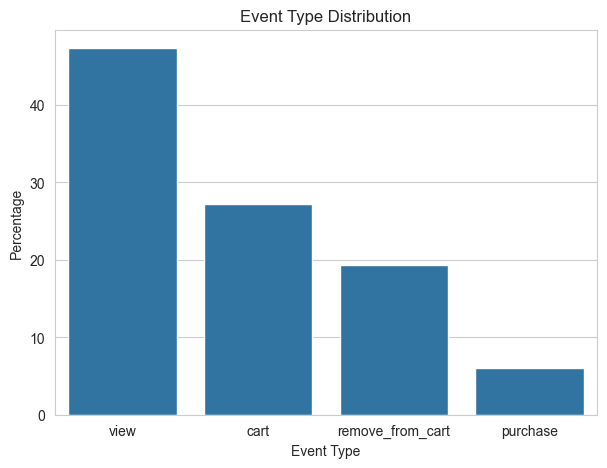

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(
    x=event_percent.index,
    y=event_percent.values)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Percentage")
plt.show()

In [13]:
view_users = set(df[df["event_type"] == "view"]["user_id"])

In [14]:
cart_users = set(df[df["event_type"] == "cart"]["user_id"])

In [15]:
purchase_users = set(df[df["event_type"] == "purchase"]["user_id"])

In [16]:
funnel = pd.DataFrame({
    "Stage": ["View", "Cart", "Purchase"],
    "Users": [
        len(view_users),
        len(cart_users),
        len(purchase_users)]})
print(funnel)

      Stage   Users
0      View  716987
1      Cart  162035
2  Purchase   49473


In [17]:
view_to_cart = (len(cart_users) / len(view_users)) * 100

In [18]:
cart_to_purchase = (len(purchase_users) / len(cart_users)) * 100

In [19]:
overall_conversion = (len(purchase_users) / len(view_users)) * 100

In [20]:
print(f"View to Cart: {view_to_cart:.2f}%")
print(f"Cart to Purchase: {cart_to_purchase:.2f}%")
print(f"Overall Conversion: {overall_conversion:.2f}%")

View to Cart: 22.60%
Cart to Purchase: 30.53%
Overall Conversion: 6.90%


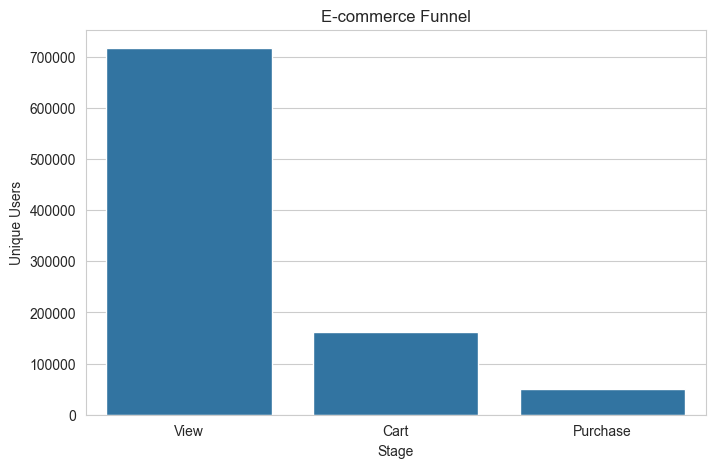

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=funnel,
    x="Stage",
    y="Users")
plt.title("E-commerce Funnel")
plt.ylabel("Unique Users")
plt.show()

In [22]:
top_categories = (df[df["event_type"] == "view"]
    ["category_code"]
    .value_counts()
    .head(8)
    .index)

In [23]:
category_results = []
for cat in top_categories:
    temp = df[df["category_code"] == cat]
    view_u = set(
        temp[temp["event_type"] == "view"]["user_id"])
    purchase_u = set(
        temp[temp["event_type"] == "purchase"]["user_id"])
    conversion = (
        len(purchase_u) / len(view_u)
    ) * 100 if len(view_u) > 0 else 0
    category_results.append([
        cat,
        round(conversion, 2)])
category_df = pd.DataFrame(
    category_results,
    columns=["Category", "Conversion_Rate"])
print(category_df)

                          Category  Conversion_Rate
0    appliances.environment.vacuum             8.85
1    furniture.living_room.cabinet             2.21
2                    apparel.glove            38.91
3              stationery.cartrige            23.77
4                  accessories.bag             1.43
5          furniture.bathroom.bath            10.66
6     appliances.personal.massager             2.62
7  appliances.personal.hair_cutter             2.45


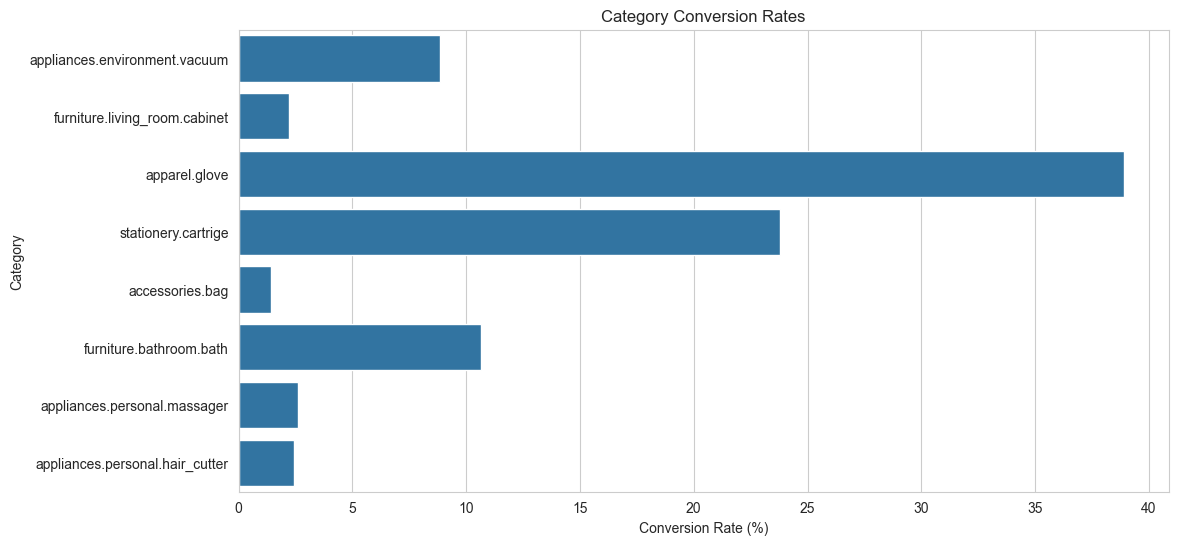

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=category_df,
    x="Conversion_Rate",
    y="Category")
plt.title("Category Conversion Rates")
plt.xlabel("Conversion Rate (%)")
plt.show()

In [25]:
monthly_conversion = []
for month in ["January", "February"]:
    temp = df[df["month"] == month]
    view_u = set(
        temp[temp["event_type"] == "view"]["user_id"])
    purchase_u = set(
        temp[temp["event_type"] == "purchase"]["user_id"])
    conversion = (
        len(purchase_u) / len(view_u)) * 100
    monthly_conversion.append([
        month,
        round(conversion, 2)])
monthly_df = pd.DataFrame(
    monthly_conversion,
    columns=["Month", "Conversion"])
print(monthly_df)

      Month  Conversion
0   January        7.09
1  February        6.79


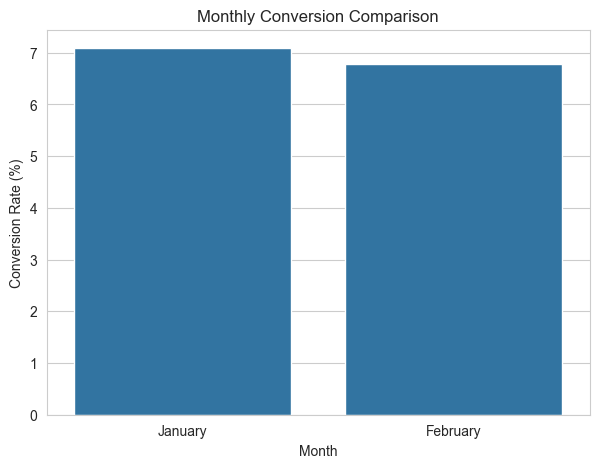

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=monthly_df,
    x="Month",
    y="Conversion")
plt.title("Monthly Conversion Comparison")
plt.ylabel("Conversion Rate (%)")
plt.show() #nisbet azalib

In [27]:
purchase_df = df[
    df["event_type"] == "purchase"]

In [28]:
top_brands = (
    purchase_df["brand"]
    .value_counts()
    .head(10))

In [29]:
print(top_brands)

brand
runail       45274
irisk        31210
grattol      21320
masura       19929
ingarden     10276
estel         8616
bpw.style     8437
uno           6871
italwax       6740
kapous        6370
Name: count, dtype: int64


In [30]:
brand_views = (
    df[df["event_type"] == "view"]
    .groupby("brand")
    .size()
    .reset_index(name="view_count"))
top_brand_df = pd.DataFrame({
    "brand": top_brands.index,
    "purchase_count": top_brands.values})
top_brand_df = top_brand_df.merge(
    brand_views,
    on="brand",
    how="left")
print(top_brand_df)

       brand  purchase_count  view_count
0     runail           45274      257004
1      irisk           31210      179851
2    grattol           21320      178970
3     masura           19929      143103
4   ingarden           10276       71516
5      estel            8616       90060
6  bpw.style            8437       43536
7        uno            6871       50047
8    italwax            6740       46180
9     kapous            6370       86521


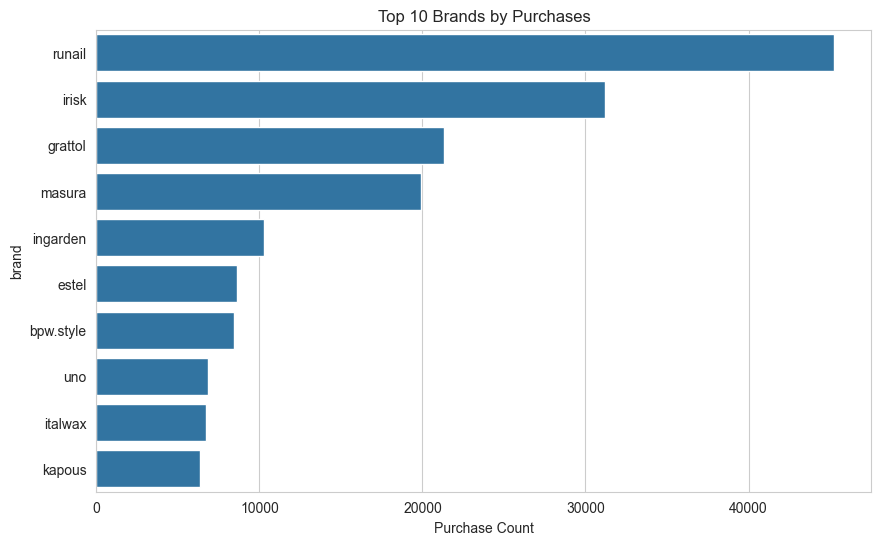

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_brand_df,
    x="purchase_count",
    y="brand")
plt.title("Top 10 Brands by Purchases")
plt.xlabel("Purchase Count")
plt.show()

In [32]:
prices = purchase_df["price"]

In [33]:
Q1 = prices.quantile(0.25)
Q3 = prices.quantile(0.75)
IQR = Q3 - Q1

In [34]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [35]:
outliers = purchase_df[
    (purchase_df["price"] < lower_bound) |
    (purchase_df["price"] > upper_bound)]
print(outliers[["price"]].head())

     price
590  14.51
591  19.37
594  15.24
596  14.13
598  14.13


In [36]:
print("Outlier Count:", len(outliers))

Outlier Count: 34947


In [37]:
views = df[df["event_type"] == "view"]
purchases = df[df["event_type"] == "purchase"] #bonus

In [38]:
merged = pd.merge(
    views,
    purchases,
    on=["user_id", "product_id"],
    suffixes=("_view", "_purchase"))

In [39]:
merged["time_diff"] = (
    merged["event_time_purchase"] - merged["event_time_view"]).dt.total_seconds() / 3600

In [40]:
avg_time = merged["time_diff"].mean()
print(f"Average Hours: {avg_time:.2f}")

Average Hours: 26.98


In [41]:
view_counts = (
    df[df["event_type"] == "view"]
    .groupby("product_id")
    .size()
    .reset_index(name="views")) #bonus

In [42]:
purchase_counts = (
    df[df["event_type"] == "purchase"]
    .groupby("product_id")
    .size()
    .reset_index(name="purchases"))

In [43]:
product_analysis = view_counts.merge(
    purchase_counts,
    on="product_id",
    how="left")
product_analysis["purchases"] = (
    product_analysis["purchases"]
    .fillna(0))

In [44]:
product_analysis["conversion"] = (
    product_analysis["purchases"] /
    product_analysis["views"]) * 100

In [45]:
low_conversion_products = (
    product_analysis[
        (product_analysis["views"] > 1000) &
        (product_analysis["conversion"] < 1)]
    .sort_values(
        by="views",
        ascending=False))
print(low_conversion_products.head())

       product_id  views  purchases  conversion
18511     5808664  17194       23.0    0.133768
36706     5877456   7800       21.0    0.269231
13277     5769877   7608       66.0    0.867508
41072     5896420   6914       26.0    0.376049
45586     5915337   5900        5.0    0.084746
